# Unified Paper, Part II: Listed-Option Hedge Capacity

**Observable Fragility, Limited Hedge Capacity, and Tail Risk in Bond ETFs**

This notebook is the hedge-capacity extension to the broad 352-ETF fragility analysis in Notebook 03. General fragility claims use the full panel; capacity regressions use the 33 covered funds, and tradeability conclusions emphasize the six funds passing the strict liquidity gate.

Sections:
1. Load Data (+ Build Panel)
2. Universe Coverage
3. Rate-Space Exposures and Hedge Capacity
4. Empirical Rate-Duration Proxy
5. Duration-Scaled Greek Exposure (Robustness)
6. Hedgeability Scores
7. Convexity Capacity and Rate Carry
8. IV-Realized Variance Gap (Appendix Diagnostic)
9. Predictive Regressions
10. Spec 0 Robustness: Within vs. Between
11. Paper Artifacts (capacity accounting, book anatomy, validation)


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns

from src import config as cfg
from src.data.options_universe import UNIVERSE, BUCKET_ORDER, ticker_bucket
from src.features.options_features import (
    add_duration_exposure_features,
    add_duration_normalized_hedgeability,
    add_latest_duration_exposure_to_panel,
    add_rate_duration_to_panel,
    compute_hedgeability_score,
    compute_vrp,
    estimate_rolling_rate_duration,
    summarize_duration_exposure,
    summarize_roll_cost_by_regime,
)
from src.analysis.regression_utils import cgm_summary

cfg.ensure_options_dirs()
sns.set_theme(style="ticks", palette="deep", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

# Duration-bucket palette used by every figure (seaborn "deep")
colors = {"short": "#4C72B0", "intermediate": "#DD8452",
          "long": "#55A868", "credit": "#C44E52", "other": "#937860"}
# Shared table and regression display helpers
from src.reporting.options_notebook import (
    compile_and_display_regressions,
    display_empirical_duration_table,
    display_hedge_capacity_table,
    display_hedgeability_scores,
    display_robustness_ladder,
    display_ticker_summary,
)

---
## 1. Load Data


In [2]:
# ── Screen outputs (read-only) ────────────────────────────────────────────
# Produced by scripts/03_concat_screen.py from the chain cache.
# Chain fetching itself: scripts/06_build_options_panel.py --repull.
# Full pipeline: python scripts/reproduce.py  (see REPRODUCING.md)
ticker_summary_built = pd.read_csv(cfg.TICKER_SUMMARY_CSV)
liquid_tickers = ticker_summary_built[ticker_summary_built["liquid"]]["ticker"].tolist()

display_ticker_summary(ticker_summary_built)


,ticker,dates_screened,mean_pass_rate,median_iv,median_dollar_vega,median_dollar_gamma,median_dollar_delta,median_sqrt_oi_notional,median_sqrt_theta_notional,median_cost_adj_depth,median_balanced_depth,median_liq_score,liquid
30,TLT,113,0.4490,0.1480,0.1140,0.0440,-25.6540,10059.9580,1216.5080,9447.5440,5808.8750,5419.4020,True
16,IEF,103,0.2980,0.0830,0.0960,0.0540,-50.2740,2910.2220,321.8780,2673.4690,991.8270,874.6060,True
20,LQD,97,0.3090,0.1190,0.1070,0.0430,-72.2320,3647.3880,416.1520,2810.9740,797.9060,643.6890,True
9,EDV,61,0.4190,0.2300,0.0820,0.0180,-33.7670,509.6370,56.3200,405.3040,232.2260,174.1700,True
10,EMB,103,0.2160,0.1670,0.1050,0.0280,-64.8180,1581.4370,180.7350,1230.0070,195.0370,157.8690,True
35,ZROZ,103,0.3880,0.2330,0.1190,0.0200,-27.4290,364.0430,38.0850,303.3000,125.2110,105.4190,True
28,TIP,103,0.2460,0.1120,0.1150,0.0390,-70.9190,449.6010,43.1390,386.4820,76.8950,69.3160,False
33,VCLT,114,0.2120,0.1430,0.0820,0.0300,-26.2860,225.7280,24.0880,190.9020,61.9030,48.1870,False
29,TLH,101,0.2940,0.1270,0.1230,0.0410,-62.1030,167.3320,13.9530,134.5180,40.6790,34.9670,False
0,AGG,103,0.2320,0.0690,0.1040,0.0700,-46.9730,227.2530,24.1580,182.9510,37.3610,31.6600,False


In [3]:
# IV panel (weekly, all 36 universe tickers)
iv_panel = pd.read_csv(cfg.IV_PANEL_CSV, parse_dates=["date"])
call_put_iv = pd.read_csv(cfg.OPTIONS_SCREEN_DIR / "call_put_iv_diagnostic.csv", parse_dates=["snap_date", "expiry"])

# Options screen outputs
ticker_summary = pd.read_csv(cfg.TICKER_SUMMARY_CSV)
chains         = pd.read_csv(cfg.CHAINS_CSV, parse_dates=["snap_date"])
screen_summary = pd.read_csv(cfg.SCREEN_SUMMARY_CSV, parse_dates=["snap_date"])

# Core panel (for fragility tercile and outcomes)
core_panel = pd.read_csv(cfg.CORE_PANEL_CSV, parse_dates=["Date"])
core_panel = core_panel.rename(columns={"Date": "date", "Symbol": "ticker"})

# Hedge-capacity panel — built by scripts/06_build_options_panel.py
if cfg.OPTIONS_PANEL_CSV.exists():
    options_panel = pd.read_csv(cfg.OPTIONS_PANEL_CSV, parse_dates=["date"])
    print(f"Options panel:  {len(options_panel):,} rows, {options_panel['ticker'].nunique()} tickers")
    hcap_coverage = options_panel["hedge_capacity_ratio"].notna().sum()
    print(f"  hedge_capacity_ratio non-null: {hcap_coverage:,}")
else:
    options_panel = pd.DataFrame()
    print("Options panel not found — run: python scripts/06_build_options_panel.py")

print(f"IV panel:       {len(iv_panel):,} rows, {iv_panel['ticker'].nunique()} tickers")
print(f"  iv_30d valid: {iv_panel['iv_30d'].notna().sum():,}")
print(f"Call/put IV diagnostic: {len(call_put_iv):,} ticker-snapshots")
print(f"  paired sides: {(call_put_iv['iv_side_count'] == 2).sum():,}")
print(f"  median absolute gap: {call_put_iv['abs_call_put_iv_gap'].median():.4f}")
print(f"Chains:         {len(chains):,} rows")
print(f"Screen summary: {len(screen_summary):,} rows")
print(f"Core panel:     {len(core_panel):,} rows")

sample_funnel_path = cfg.TABLES_DIR / "sample_funnel.csv"
if sample_funnel_path.exists():
    print("\nNested samples used by the unified paper:")
    display(pd.read_csv(sample_funnel_path).round(2))
else:
    print("\nSample funnel not found; run: python scripts/08_paper_artifacts.py")


Options panel:  18,056 rows, 36 tickers
  hedge_capacity_ratio non-null: 12,599
IV panel:       18,056 rows, 36 tickers
  iv_30d valid: 7,195
Call/put IV diagnostic: 2,367 ticker-snapshots
  paired sides: 784
  median absolute gap: 0.0078
Chains:         339,220 rows
Screen summary: 3,046 rows
Core panel:     159,216 rows


---
## 2. Nested Samples and Universe Coverage


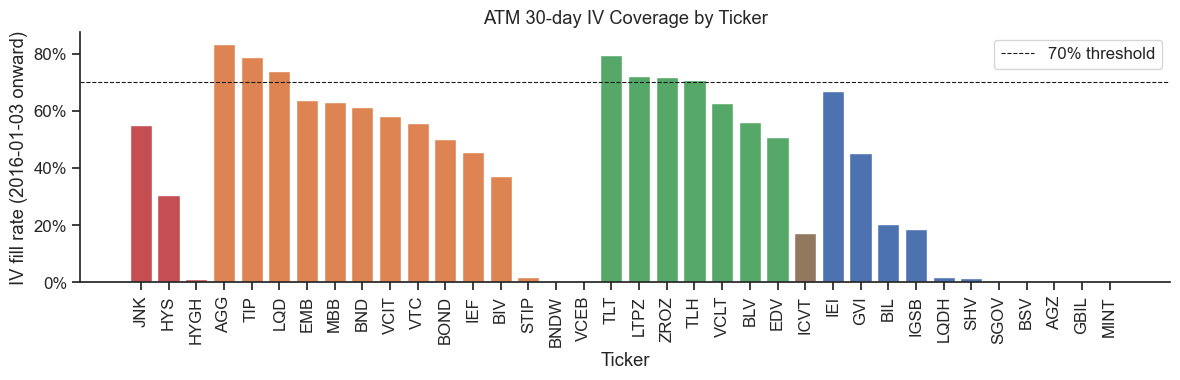


7 tickers >= 70% fill: ['AGG', 'LQD', 'LTPZ', 'TIP', 'TLH', 'TLT', 'ZROZ']
ticker  fill_rate duration_bucket
   JNK     0.5502          credit
   HYS     0.3050          credit
  HYGH     0.0135          credit
   AGG     0.8340    intermediate
   TIP     0.7876    intermediate
   LQD     0.7375    intermediate
   EMB     0.6390    intermediate
   MBB     0.6313    intermediate
   BND     0.6120    intermediate
  VCIT     0.5830    intermediate
   VTC     0.5585    intermediate
  BOND     0.5019    intermediate
   IEF     0.4556    intermediate
   BIV     0.3707    intermediate
  STIP     0.0174    intermediate
  BNDW     0.0000    intermediate
  VCEB     0.0000    intermediate
   TLT     0.7954            long
  LTPZ     0.7220            long
  ZROZ     0.7181            long
   TLH     0.7085            long
  VCLT     0.6255            long
   BLV     0.5618            long
   EDV     0.5077            long
  ICVT     0.1718           other
   IEI     0.6680           short
   GVI

In [4]:
# Attach duration bucket to IV panel
iv_panel["category"] = iv_panel["ticker"].map(UNIVERSE)
iv_panel["duration_bucket"] = iv_panel["ticker"].map(ticker_bucket)

# Coverage is measured only over the IV-fetch window.
IV_START = "2016-01-03"
iv_window = iv_panel[iv_panel["date"] >= IV_START]
coverage = (
    iv_window.groupby("ticker")["iv_30d"]
    .apply(lambda s: s.notna().mean())
    .rename("fill_rate")
    .reset_index()
)
coverage["duration_bucket"] = coverage["ticker"].map(ticker_bucket)
coverage = coverage.sort_values(["duration_bucket", "fill_rate"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(coverage["ticker"], coverage["fill_rate"], color=coverage["duration_bucket"].map(colors))
ax.axhline(0.7, color="k", ls="--", lw=0.8, label="70% threshold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(xlabel="Ticker", ylabel=f"IV fill rate ({IV_START} onward)", title="ATM 30-day IV Coverage by Ticker")
ax.legend()
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "01_iv_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

above_70 = coverage.loc[coverage["fill_rate"] >= 0.7, "ticker"].tolist()
print(f"\n{len(above_70)} tickers >= 70% fill: {sorted(above_70)}")
print(coverage.to_string(index=False))


---
## 3. Rate-Space Exposures and Hedge Capacity

`hedge_capacity_ratio` = chain-level DV01 (option OI × rate_dv01 per contract) divided by fund DV01 (D_i × AUM × 0.0001). By the D_i cancellation identity, this reduces to `(100 · S · Σ|delta| · w) / AUM` — robust to noisy empirical duration estimates. It is an optimistic stock-of-open-interest measure, not executable order-book depth: it ignores price impact and treats qualifying OI as potentially available.

Loaded from `options_panel.csv` (built by Step 4 above or `scripts/06_build_options_panel.py`).


In [5]:
if not options_panel.empty:
    hcap_by_ticker = display_hedge_capacity_table(options_panel)


,ticker,duration_bucket,hcap_median,hcap_mean,weight_basis_mode,snap_dates
15,IEI,short,0.0003,0.0017,open_interest,494
23,SGOV,short,0.0000,0.0000,open_interest,68
16,IGSB,short,0.0000,0.0000,open_interest,329
1,AGZ,short,0.0000,0.0000,open_interest,203
2,BIL,short,0.0000,0.0000,open_interest,337
7,BSV,short,0.0000,0.0000,open_interest,246
10,GVI,short,0.0000,0.0000,open_interest,325
19,LQDH,short,0.0000,0.0000,open_interest,268
22,MINT,short,0.0000,0.0000,open_interest,259
24,SHV,short,0.0000,0.0000,open_interest,216


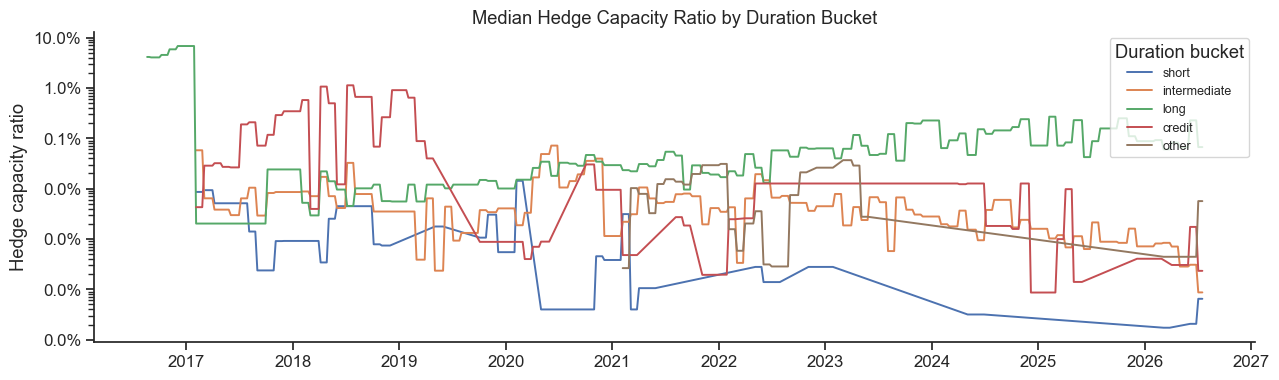

In [6]:
if not options_panel.empty and "hedge_capacity_ratio" in options_panel.columns:
    op = options_panel.dropna(subset=["hedge_capacity_ratio"]).copy()
    op["duration_bucket"] = op["ticker"].map(ticker_bucket)
    ts = (
        op.groupby(["date", "duration_bucket"])["hedge_capacity_ratio"]
        .median()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(13, 4))
    for bucket in BUCKET_ORDER:
        sub = ts[(ts["duration_bucket"] == bucket) & (ts["hedge_capacity_ratio"] > 0)]
        if not sub.empty:
            ax.plot(sub["date"], sub["hedge_capacity_ratio"], label=bucket,
                    color=colors.get(bucket), linewidth=1.4)
    ax.set_title("Median Hedge Capacity Ratio by Duration Bucket")
    ax.set_ylabel("Hedge capacity ratio")
    ax.set_yscale("log")
    ax.legend(title="Duration bucket", loc="upper right", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    sns.despine()
    plt.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / "hcap_ratio_ts.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skip: options_panel.csv not built yet.")


---
## 4. Empirical Rate-Duration Proxy

Rate-duration estimated by regressing weekly ETF returns on `d_DGS10` (weekly change in 10-year Treasury yield, in percentage points). `realized_rate_duration = −100 × beta_rate` (positive for long-duration ETFs; 52-week trailing window, min 40 observations).


In [7]:
# Rolling empirical duration from weekly ETF returns on 10-year yield changes.
# d_DGS10 is in percentage points, so duration = -100 * return beta.
core_duration_input = core_panel[core_panel["ticker"].isin(list(UNIVERSE.keys()))].copy()

duration_est = estimate_rolling_rate_duration(
    core_duration_input,
    window=52,
    min_obs=40,
    return_col="Return",
    yield_col="d_DGS10",
)

duration_latest = (
    duration_est.sort_values("date")
    .groupby("ticker", as_index=False)
    .tail(1)
)
duration_latest = duration_latest[duration_latest["ticker"].isin(list(UNIVERSE.keys()))].copy()
duration_latest["duration_bucket"] = duration_latest["ticker"].map(ticker_bucket)
bucket_order_map = {bucket: i for i, bucket in enumerate(BUCKET_ORDER)}
duration_latest["bucket_order"] = duration_latest["duration_bucket"].map(bucket_order_map)
duration_latest = (
    duration_latest
    .sort_values(["bucket_order", "realized_rate_duration"], ascending=[True, False])
    .drop(columns="bucket_order")
)

duration_latest.to_csv(cfg.TABLES_DIR / "empirical_duration_by_ticker.csv", index=False)



display_empirical_duration_table(duration_latest)


,ticker,duration_bucket,date,realized_rate_duration,realized_rate_duration_raw,duration_r2,duration_nobs
8508,IEI,short,2026-07-17,4.4851,4.4851,0.9087,52
6113,GVI,short,2026-07-17,3.6312,3.6312,0.8856,52
957,AGZ,short,2026-07-17,2.8604,2.8604,0.7294,52
8987,IGSB,short,2026-07-17,2.5936,2.5936,0.7149,52
4202,BSV,short,2026-07-17,2.5290,2.5290,0.7989,52
10424,LQDH,short,2026-07-17,0.2364,0.2364,0.0024,52
12620,SHV,short,2026-07-17,0.0758,0.0758,0.1712,52
5634,GBIL,short,2026-07-17,0.0660,0.0660,0.1249,52
11861,MINT,short,2026-07-17,0.0152,0.0152,0.0014,52
1436,BIL,short,2026-07-17,-0.0002,-0.0002,0.0000,52


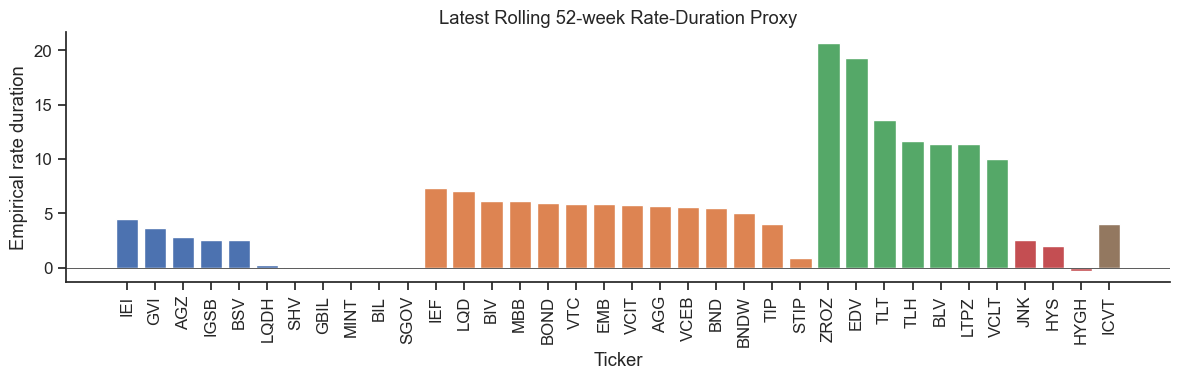

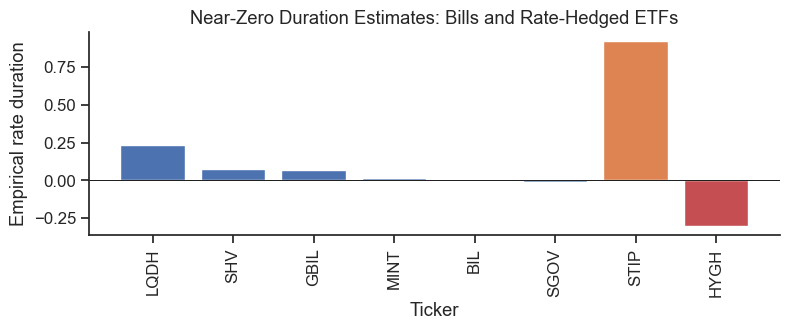

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(duration_latest["ticker"], duration_latest["realized_rate_duration"],
       color=duration_latest["duration_bucket"].map(colors))
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="Ticker", ylabel="Empirical rate duration",
       title="Latest Rolling 52-week Rate-Duration Proxy")
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "08_empirical_rate_duration_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()

# Zoom the near-zero estimates that are compressed in the all-ticker chart.
low_duration = duration_latest[duration_latest["realized_rate_duration"].abs() <= 1.0].copy()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(low_duration["ticker"], low_duration["realized_rate_duration"],
       color=low_duration["duration_bucket"].map(colors))
ax.axhline(0, color="k", lw=0.7)
ax.set(xlabel="Ticker", ylabel="Empirical rate duration",
       title="Near-Zero Duration Estimates: Bills and Rate-Hedged ETFs")
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "09_empirical_rate_duration_zoom.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5. Duration-Scaled Greek Exposure (Robustness)

Legacy Greek-scaling approach (no OI required). Main purpose: cross-check that duration-normalized vega capacity aligns directionally with `hedge_capacity_ratio` from Section 3.


In [9]:
chains_duration = add_duration_exposure_features(chains, duration_est)
chains_duration = chains_duration[chains_duration["ticker"].isin(list(UNIVERSE.keys()))].copy()
chains_duration["duration_bucket"] = chains_duration["ticker"].map(ticker_bucket)

duration_exposure_summary, duration_exposure_by_ticker, duration_exposure_by_date_bucket, duration_exposure_by_ticker_date = summarize_duration_exposure(
    chains_duration,
    bucket_order=BUCKET_ORDER,
)

duration_exposure_sample = chains_duration.dropna(
    subset=[
        "realized_rate_duration", "dollar_duration", "duration_per_vega",
        "gamma_per_duration", "theta_per_duration",
    ]
).copy()

bucket_order_map = {bucket: i for i, bucket in enumerate(BUCKET_ORDER)}
duration_exposure_by_ticker["bucket_order"] = duration_exposure_by_ticker["duration_bucket"].map(bucket_order_map)
duration_exposure_by_ticker = (
    duration_exposure_by_ticker
    .sort_values(["bucket_order", "realized_rate_duration_mean"], ascending=[True, False])
    .drop(columns="bucket_order")
)

DISPLAY_MIN_QUALITY_CONTRACTS = 50
DISPLAY_MIN_QUALITY_SHARE = 0.25
quality_display_mask = (
    (duration_exposure_by_ticker["quality_contracts"] >= DISPLAY_MIN_QUALITY_CONTRACTS)
    & (duration_exposure_by_ticker["quality_share"] >= DISPLAY_MIN_QUALITY_SHARE)
)
duration_exposure_by_ticker["quality_display"] = quality_display_mask
quality_display_tickers = duration_exposure_by_ticker.loc[quality_display_mask, "ticker"]

_display_quality_cols = [
    "vega_per_100_duration_quality_median",
    "gamma_per_100_duration_quality_median",
    "theta_bp_per_duration_quality_median",
]
for col in _display_quality_cols:
    duration_exposure_by_ticker[f"{col}_display"] = duration_exposure_by_ticker[col].where(
        duration_exposure_by_ticker["quality_display"]
    )

duration_exposure_by_ticker_date_display = duration_exposure_by_ticker_date[
    duration_exposure_by_ticker_date["ticker"].isin(quality_display_tickers)
].copy()
duration_exposure_by_date_bucket_display = (
    duration_exposure_by_ticker_date_display
    .groupby(["snap_date", "duration_bucket"])
    .agg(
        dollar_duration_median=("dollar_duration_median", "median"),
        vega_per_100_dur_median=("vega_per_100_duration_quality_median", "median"),
    )
    .reset_index()
)

duration_exposure_summary.to_csv(cfg.TABLES_DIR / "duration_exposure_summary.csv", index=False)
duration_exposure_by_ticker.to_csv(cfg.TABLES_DIR / "duration_exposure_by_ticker.csv", index=False)
duration_exposure_by_ticker_date.to_csv(cfg.TABLES_DIR / "duration_exposure_by_ticker_date.csv", index=False)

print("Duration-scaled Greek exposures by duration bucket:")
print(duration_exposure_summary.set_index("duration_bucket").round(4))
print(f"\nRows with duration-scaled ratios: {len(duration_exposure_sample):,} / {len(chains_duration):,}")
print(f"Rows passing duration-quality guards: {int(duration_exposure_sample['duration_quality'].sum()):,}")


Duration-scaled Greek exposures by duration bucket:
                 realized_rate_duration_mean  realized_rate_duration_median  \
duration_bucket                                                               
short                                 2.1225                         2.3844   
intermediate                          6.2187                         6.7802   
long                                 16.5040                        15.5335   
credit                                0.5077                         0.3976   
other                                 0.2627                        -0.5012   

                 duration_r2_mean  dollar_duration_median  \
duration_bucket                                             
short                      0.5230                 -5.6768   
intermediate               0.6656               -124.1199   
long                       0.8300               -100.4671   
credit                     0.1124                -12.1711   
other                      0

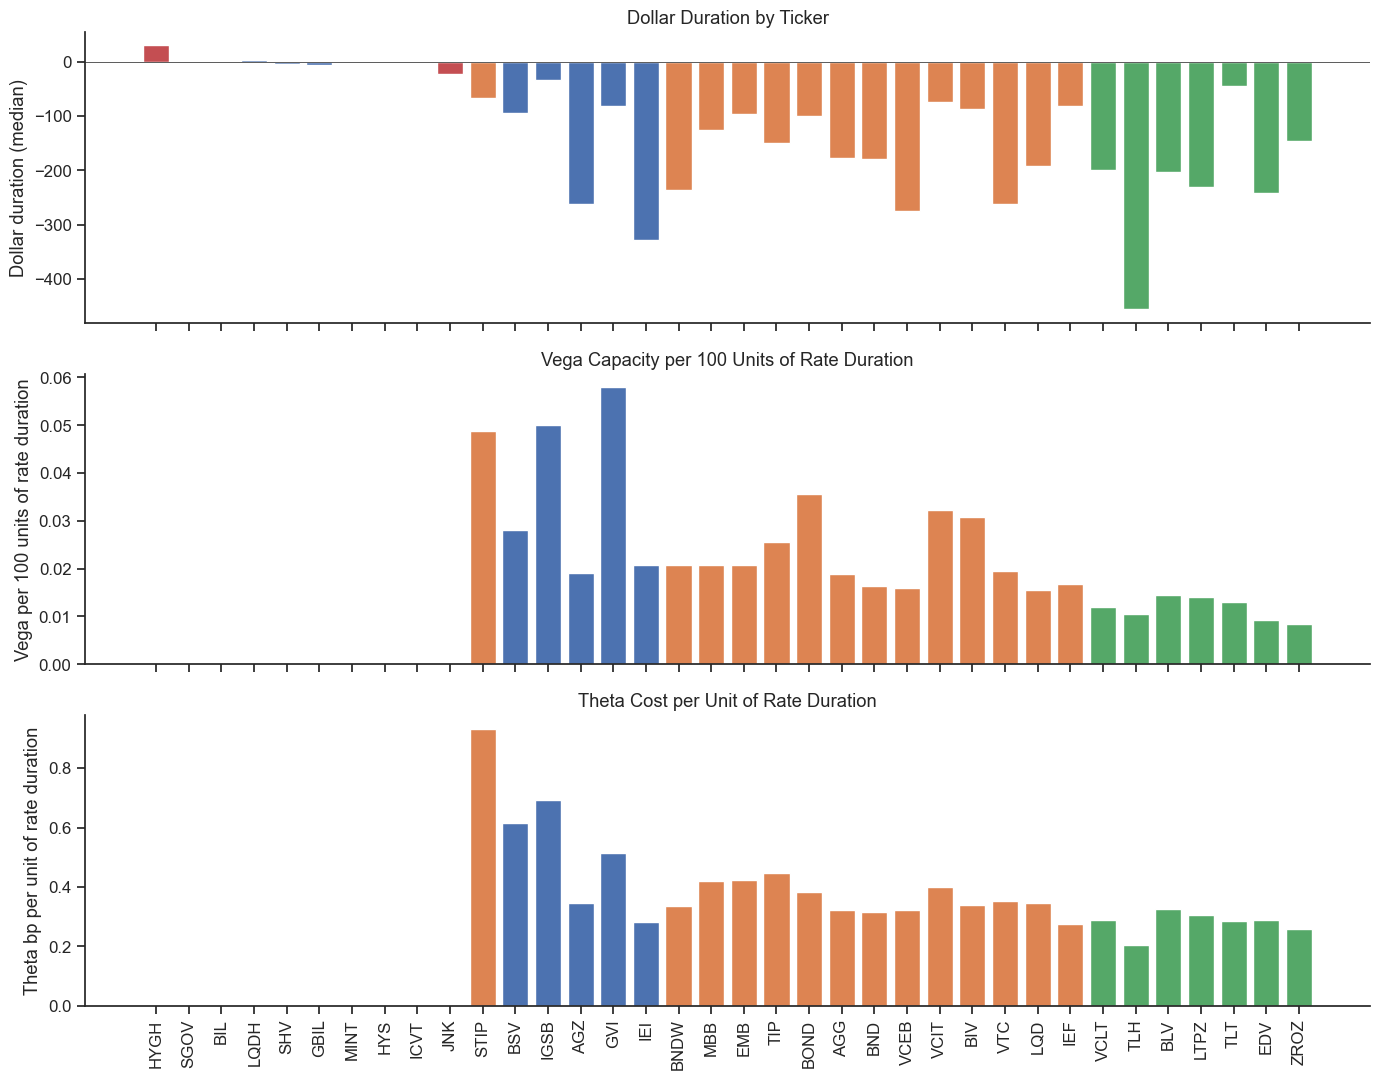

In [10]:
# Cross-sectional duration-scaled Greek exposure, ordered low to high duration.
ordered = duration_exposure_by_ticker.sort_values("realized_rate_duration_mean", ascending=True)
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

def _duration_bar(ax, col, ylabel, title):
    vals = ordered[col]
    bar_colors = ordered["duration_bucket"].map(colors).where(vals.notna(), "#cccccc")
    ax.bar(ordered["ticker"], vals, color=bar_colors)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    sns.despine(ax=ax)

_duration_bar(axes[0], "dollar_duration_median",
              "Dollar duration (median)", "Dollar Duration by Ticker")
_duration_bar(axes[1], "vega_per_100_duration_quality_median_display",
              "Vega per 100 units of rate duration",
              "Vega Capacity per 100 Units of Rate Duration")
_duration_bar(axes[2], "theta_bp_per_duration_quality_median_display",
              "Theta bp per unit of rate duration",
              "Theta Cost per Unit of Rate Duration")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "10_duration_scaled_greeks_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()


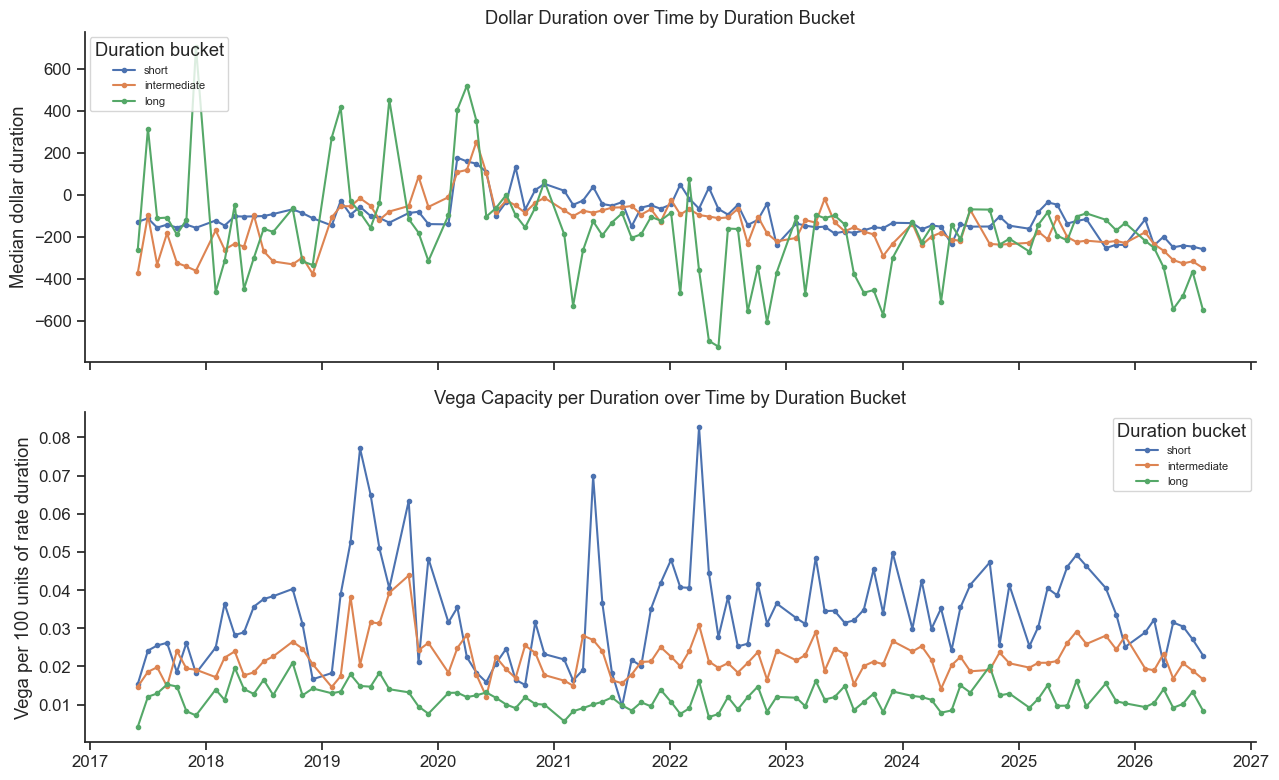

In [11]:
# Duration-scaled Greek exposure across monthly snapshots.
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for bucket in BUCKET_ORDER:
    sub = duration_exposure_by_date_bucket_display[
        duration_exposure_by_date_bucket_display["duration_bucket"] == bucket
    ]
    if sub.empty:
        continue
    c = colors.get(bucket, "#888888")
    axes[0].plot(sub["snap_date"], sub["dollar_duration_median"],
                 label=bucket, color=c, marker="o", ms=3)
    axes[1].plot(sub["snap_date"], sub["vega_per_100_dur_median"],
                 label=bucket, color=c, marker="o", ms=3)

axes[0].set_ylabel("Median dollar duration")
axes[0].set_title("Dollar Duration over Time by Duration Bucket")
axes[0].legend(title="Duration bucket", loc="upper left", fontsize=8)
axes[1].set_ylabel("Vega per 100 units of rate duration")
axes[1].set_title("Vega Capacity per Duration over Time by Duration Bucket")
axes[1].legend(title="Duration bucket", loc="upper right", fontsize=8)
sns.despine()
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "12_duration_greeks_time_series.png", dpi=150, bbox_inches="tight")
plt.show()


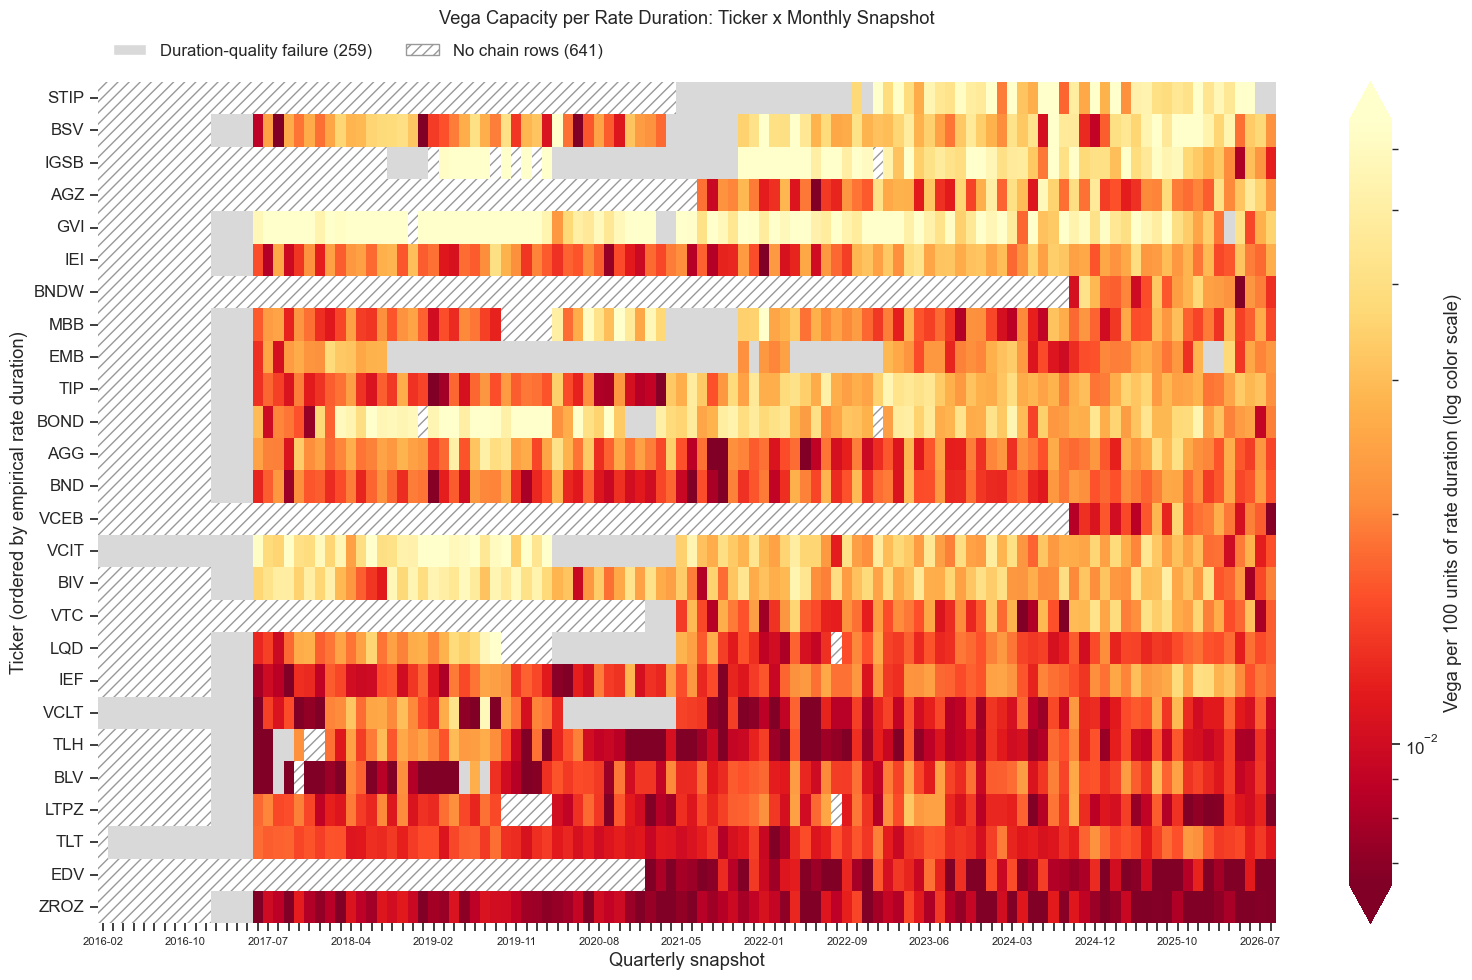

Missing heatmap cells: 900 = 259 duration-quality failures + 641 no-chain cells


In [12]:
# Heatmap: vega capacity per duration by ticker and monthly snapshot.
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch, Rectangle

heatmap_df = duration_exposure_by_ticker_date_display.pivot(
    index="ticker", columns="snap_date",
    values="vega_per_100_duration_quality_median",
)
ticker_dur_order = (
    duration_exposure_by_ticker
    .sort_values("realized_rate_duration_mean", ascending=True)["ticker"]
    .tolist()
)
heatmap_tickers = [t for t in ticker_dur_order if t in quality_display_tickers.values]
heatmap_dates = sorted(pd.to_datetime(chains_duration["snap_date"].dropna().unique()))
heatmap_df = heatmap_df.reindex(index=heatmap_tickers, columns=heatmap_dates)

# Gray cells failed the duration-quality gate; hatched cells have no chain rows.
observed_pairs = set(zip(chains_duration["ticker"], pd.to_datetime(chains_duration["snap_date"])))
missing_cells = int(heatmap_df.isna().sum().sum())
no_chain_cells = 0
heatmap_values = heatmap_df.stack().dropna()
color_min, color_max = heatmap_values.quantile([0.05, 0.95])
date_labels = [pd.Timestamp(d).strftime("%Y-%m") if i % 8 == 0 else ""
               for i, d in enumerate(heatmap_df.columns)]
cmap = plt.get_cmap("YlOrRd_r").copy()
cmap.set_bad("#d9d9d9")
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(heatmap_df, ax=ax, cmap=cmap,
            norm=LogNorm(vmin=color_min, vmax=color_max), xticklabels=date_labels,
            cbar_kws={"label": "Vega per 100 units of rate duration (log color scale)",
                       "extend": "both"})
for row_i, ticker in enumerate(heatmap_df.index):
    for col_i, snap_date in enumerate(heatmap_df.columns):
        if pd.isna(heatmap_df.iloc[row_i, col_i]) and (ticker, snap_date) not in observed_pairs:
            no_chain_cells += 1
            ax.add_patch(Rectangle((col_i, row_i), 1, 1, facecolor="white",
                                   edgecolor="#999999", hatch="///", linewidth=0.0))
duration_fail_cells = missing_cells - no_chain_cells
ax.legend(handles=[
    Patch(facecolor="#d9d9d9", label=f"Duration-quality failure ({duration_fail_cells})"),
    Patch(facecolor="white", edgecolor="#999999", hatch="///",
          label=f"No chain rows ({no_chain_cells})"),
], loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False)
ax.set(xlabel="Quarterly snapshot",
       ylabel="Ticker (ordered by empirical rate duration)",
       title="Vega Capacity per Rate Duration: Ticker x Monthly Snapshot")
ax.set_title(ax.get_title(), pad=42)
ax.tick_params(axis="x", rotation=0, labelsize=8)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "13_vega_per_duration_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Missing heatmap cells: {missing_cells} = "
      f"{duration_fail_cells} duration-quality failures + {no_chain_cells} no-chain cells")


---
## 6. Hedgeability Scores


In [13]:
hedge = compute_hedgeability_score(
    ticker_summary,
    core_panel.rename(columns={"ticker": "Symbol"}),
)
hedge = add_duration_normalized_hedgeability(
    hedge,
    duration_exposure_by_ticker,
    min_quality_contracts=DISPLAY_MIN_QUALITY_CONTRACTS,
    min_quality_share=DISPLAY_MIN_QUALITY_SHARE,
)

hedge.to_csv(cfg.TABLES_DIR / "hedgeability_scores.csv", index=False)

display_hedgeability_scores(hedge)


Hedgeability scores: 6 liquid tickers
  H_dur coverage: 6 / 6


,ticker,H,hedgeability_tercile,fragility_tercile,fragility_hedgeability_group,H_dur
4,TLT,2.6012,3,2,F2_H3,1.2301
5,ZROZ,0.6033,3,3,F3_H3,-0.9657
3,LQD,0.3845,2,1,F1_H2,-0.3890
2,IEF,0.2302,2,1,F1_H2,2.0319
1,EMB,-1.8539,1,2,F2_H1,-1.0951
0,EDV,-1.9653,1,3,F3_H1,-0.8121


---
## 7. Convexity Capacity and Rate Carry

`convexity_capacity_ratio` measures the option chain's convexity (rate_conv) relative to the fund's dollar convexity. Unlike `hedge_capacity_ratio`, D_i does not cancel here — it scales as D_i², making it more sensitive to duration estimation noise and more informative about convexity-premium opportunities in long-duration funds.

`median_rate_carry` = median daily theta cost per unit of rate DV01 across quality contracts. High carry = expensive hedge; low carry = cheap insurance per unit of rate protection.

Both sourced from `options_panel.csv`.


In [14]:
if options_panel.empty:
    print("Skip: options_panel.csv not built yet.")
else:
    # ── Convexity capacity ratio by ticker ───────────────────────────────────
    op = options_panel.copy()
    op["duration_bucket"] = op["ticker"].map(ticker_bucket)

    conv_cols = ["ticker", "date", "duration_bucket",
                 "convexity_capacity_ratio", "hedge_capacity_ratio", "median_rate_carry"]
    op_conv = op[[c for c in conv_cols if c in op.columns]].dropna(subset=["convexity_capacity_ratio"])

    conv_by_ticker = (
        op_conv.groupby("ticker")
        .agg(
            conv_median=("convexity_capacity_ratio", "median"),
            hcap_median=("hedge_capacity_ratio", "median"),
            carry_median=("median_rate_carry", "median"),
        )
        .reset_index()
    )
    conv_by_ticker["duration_bucket"] = conv_by_ticker["ticker"].map(ticker_bucket)
    conv_by_ticker = conv_by_ticker.sort_values("conv_median", ascending=False)
    conv_by_ticker.to_csv(cfg.TABLES_DIR / "convexity_carry_by_ticker.csv", index=False)

    print("Convexity capacity ratio and rate carry by ticker (medians):")
    print(conv_by_ticker.round(6).to_string(index=False))


Convexity capacity ratio and rate carry by ticker (medians):
ticker  conv_median  hcap_median  carry_median duration_bucket
   TLT      75.1846       0.0476        0.0024            long
   IEF      35.7382       0.0126        0.0024    intermediate
   LQD      12.2250       0.0104        0.0029    intermediate
   IEI       1.4262       0.0003        0.0026           short
   TIP       1.0883       0.0008        0.0030    intermediate
   EDV       0.7867       0.0014        0.0021            long
  ZROZ       0.5132       0.0010        0.0022            long
  VCLT       0.2547       0.0002        0.0023            long
  LTPZ       0.1535       0.0004        0.0019            long
   TLH       0.1335       0.0001        0.0018            long
   BLV       0.0885       0.0001        0.0023            long
   EMB       0.0738       0.0015        0.0040    intermediate
   AGG       0.0626       0.0000        0.0025    intermediate
   JNK       0.0216       0.0004        0.0067          c

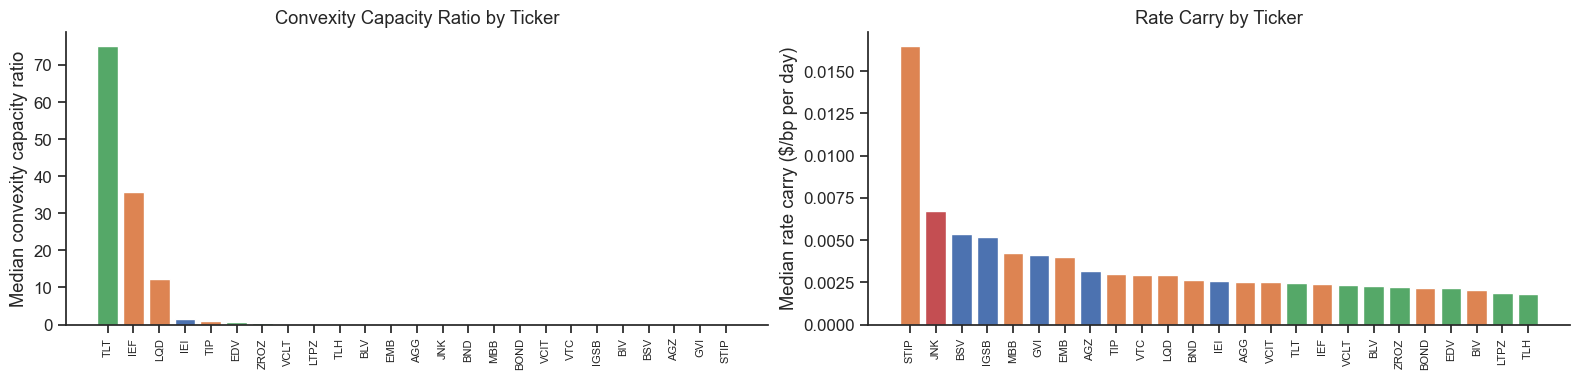

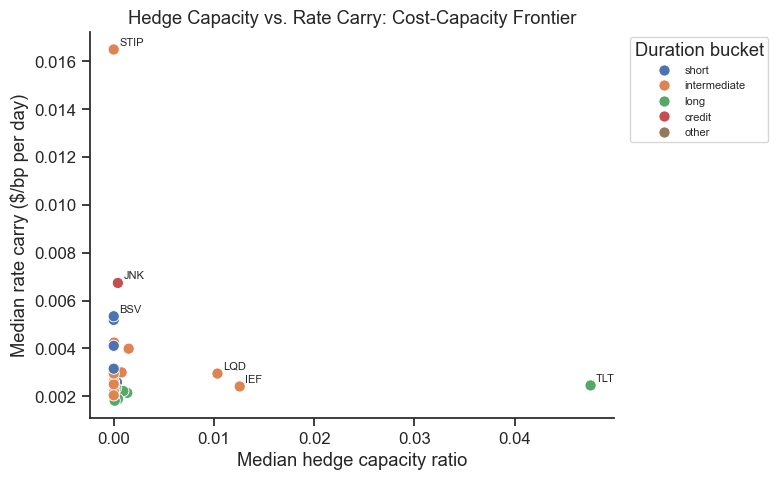

In [15]:
if not options_panel.empty and not conv_by_ticker.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    def _capacity_bar(ax, df, col, ylabel, title):
        plot_df = df.dropna(subset=[col]).sort_values(col, ascending=False)
        ax.bar(plot_df["ticker"], plot_df[col], color=plot_df["duration_bucket"].map(colors))
        ax.axhline(0, color="k", lw=0.5)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
        sns.despine(ax=ax)

    _capacity_bar(axes[0], conv_by_ticker, "conv_median",
                  "Median convexity capacity ratio", "Convexity Capacity Ratio by Ticker")
    _capacity_bar(axes[1], conv_by_ticker, "carry_median",
                  "Median rate carry ($/bp per day)", "Rate Carry by Ticker")
    plt.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / "22_convexity_carry_by_ticker.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Cost-capacity frontier. Label the extremes to keep the dense origin readable.
    scatter = conv_by_ticker.dropna(subset=["hcap_median", "carry_median"]).copy()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=scatter, x="hcap_median", y="carry_median",
                    hue="duration_bucket", hue_order=BUCKET_ORDER, palette=colors,
                    s=65, ax=ax)
    label_tickers = set(scatter.nlargest(3, "hcap_median")["ticker"])
    label_tickers.update(scatter.nlargest(3, "carry_median")["ticker"])
    for _, row in scatter[scatter["ticker"].isin(label_tickers)].iterrows():
        ax.annotate(row["ticker"], (row["hcap_median"], row["carry_median"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.set(xlabel="Median hedge capacity ratio",
           ylabel="Median rate carry ($/bp per day)",
           title="Hedge Capacity vs. Rate Carry: Cost-Capacity Frontier")
    ax.legend(title="Duration bucket", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    sns.despine()
    plt.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / "23_hcap_vs_carry_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()


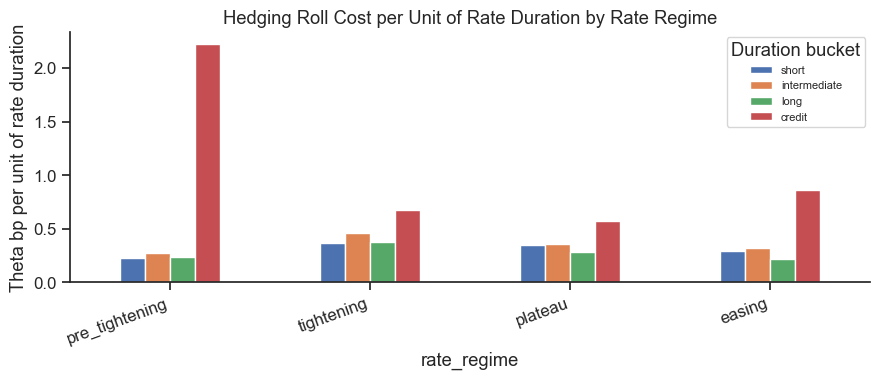

Roll-cost regime summary, quality-filtered ticker-snap medians:
   rate_regime duration_bucket  theta_p25  theta_median  theta_p75  theta_change_vs_pre  theta_ratio_vs_pre  ticker_snap_obs  tickers
pre_tightening           short     0.1873        0.2225     0.3811               0.0000              1.0000               34        3
pre_tightening    intermediate     0.1939        0.2713     0.3784               0.0000              1.0000              203       10
pre_tightening            long     0.1873        0.2360     0.2844               0.0000              1.0000              145        7
pre_tightening          credit     2.2260        2.2260     2.2260               0.0000              1.0000                1        1
    tightening           short     0.3116        0.3710     0.5550               0.1485              1.6675               29        4
    tightening    intermediate     0.3367        0.4576     0.5464               0.1863              1.6869              124       1

In [16]:
# Section 7 — Roll-cost regime summary from ticker × snap-date exposure rows
RATE_REGIME_ORDER = ["pre_tightening", "tightening", "plateau", "easing"]

roll_cost_by_regime, roll_cost_time_series, roll_cost_vega_tradeoff = summarize_roll_cost_by_regime(
    duration_exposure_by_ticker_date,
    bucket_order=BUCKET_ORDER,
    min_quality_contracts=DISPLAY_MIN_QUALITY_CONTRACTS,
    min_quality_share=DISPLAY_MIN_QUALITY_SHARE,
)

roll_cost_by_regime.to_csv(cfg.TABLES_DIR / "roll_cost_by_regime.csv", index=False)
roll_cost_time_series.to_csv(cfg.TABLES_DIR / "roll_cost_time_series.csv", index=False)
roll_cost_vega_tradeoff.to_csv(cfg.TABLES_DIR / "roll_cost_vega_tradeoff.csv", index=False)

theta_by_regime = (
    roll_cost_by_regime
    .pivot(index="rate_regime", columns="duration_bucket", values="theta_median")
    .reindex(RATE_REGIME_ORDER)
    [[b for b in BUCKET_ORDER if b in roll_cost_by_regime["duration_bucket"].astype(str).unique()]]
)

fig, ax = plt.subplots(figsize=(9, 4))
theta_by_regime.plot(kind="bar", ax=ax,
                     color=[colors.get(str(b), "#888888") for b in theta_by_regime.columns])
ax.set_ylabel("Theta bp per unit of rate duration")
ax.set_title("Hedging Roll Cost per Unit of Rate Duration by Rate Regime")
ax.legend(title="Duration bucket", bbox_to_anchor=(1, 1), fontsize=8)
ax.set_xticklabels(theta_by_regime.index, rotation=20, ha="right")
sns.despine()
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "15_roll_cost_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

print("Roll-cost regime summary, quality-filtered ticker-snap medians:")
print(roll_cost_by_regime[[
    "rate_regime", "duration_bucket", "theta_p25", "theta_median", "theta_p75",
    "theta_change_vs_pre", "theta_ratio_vs_pre", "ticker_snap_obs", "tickers",
]].round(4).to_string(index=False))


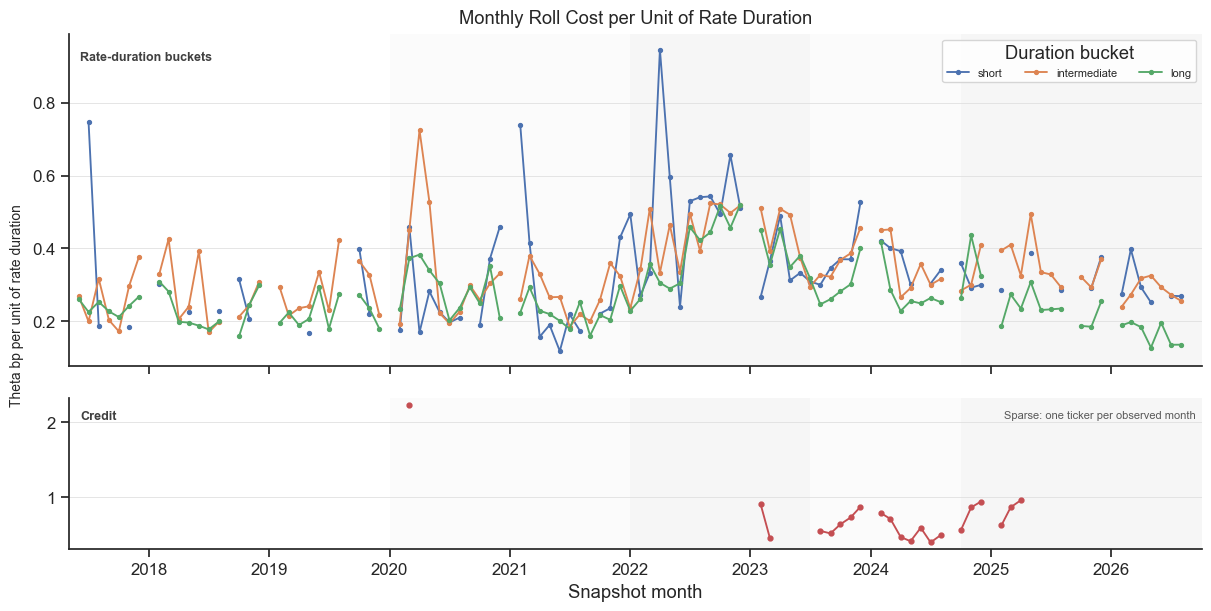

In [17]:
# Monthly roll-cost time series. Credit is separated because its history is sparse
# and each displayed month is supported by only one ticker. Reindexing to a complete
# monthly calendar prevents lines from bridging months with no observations.
def _complete_monthly_series(frame, bucket):
    sub = frame[frame["duration_bucket"].astype(str) == bucket].copy()
    sub["month"] = pd.to_datetime(sub["snap_date"]).dt.to_period("M")
    values = sub.set_index("month")["theta_median"].sort_index()
    months = pd.period_range(values.index.min(), values.index.max(), freq="M")
    return values.reindex(months).rename_axis("month")

fig, (ax, ax_credit) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, layout="constrained",
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.08},
)
core_buckets = [b for b in ["short", "intermediate", "long"]
                if b in roll_cost_time_series["duration_bucket"].astype(str).unique()]
for bucket in core_buckets:
    series = _complete_monthly_series(roll_cost_time_series, bucket)
    ax.plot(series.index.to_timestamp(), series, marker="o", ms=2.8, lw=1.35,
            label=bucket, color=colors.get(bucket))

credit = _complete_monthly_series(roll_cost_time_series, "credit")
ax_credit.plot(credit.index.to_timestamp(), credit, marker="o", ms=3.5, lw=1.35,
               color=colors.get("credit"), label="credit")

plot_start = pd.to_datetime(roll_cost_time_series["snap_date"]).min() - pd.Timedelta(days=30)
plot_end = pd.to_datetime(roll_cost_time_series["snap_date"]).max() + pd.Timedelta(days=60)
regime_spans = [
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2022-01-01"), 0.15),
    (pd.Timestamp("2022-01-01"), pd.Timestamp("2023-07-01"), 0.35),
    (pd.Timestamp("2023-07-01"), pd.Timestamp("2024-10-01"), 0.15),
    (pd.Timestamp("2024-10-01"), plot_end, 0.35),
]
for panel in (ax, ax_credit):
    for start, end, alpha in regime_spans:
        panel.axvspan(max(start, plot_start), min(end, plot_end),
                     color="0.9", alpha=alpha, lw=0, zorder=0)
    panel.grid(axis="y", color="0.88", lw=0.6)
    panel.set_xlim(plot_start, plot_end)

ax.set_title("Monthly Roll Cost per Unit of Rate Duration", pad=8)
ax.legend(title="Duration bucket", ncol=3, loc="upper right", fontsize=8)
ax.text(0.01, 0.95, "Rate-duration buckets", transform=ax.transAxes,
        ha="left", va="top", fontsize=9, weight="bold", color="0.25")
ax_credit.text(0.01, 0.92, "Credit", transform=ax_credit.transAxes,
               ha="left", va="top", fontsize=9, weight="bold", color="0.25")
ax_credit.set_xlabel("Snapshot month")
ax_credit.text(0.995, 0.92, "Sparse: one ticker per observed month",
               transform=ax_credit.transAxes, ha="right", va="top",
               fontsize=8, color="0.35")
fig.supylabel("Theta bp per unit of rate duration", fontsize=10)
sns.despine(fig=fig)
fig.savefig(cfg.FIGURES_DIR / "16_roll_cost_time_series.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 8. IV-Realized Variance Gap (Appendix Diagnostic)

IVRVG = iv² − RV² (ex-ante, no lookahead). The null-test regressions in Section 9 show IVRVG is not a robust predictor of returns or forward volatility. This appendix diagnostic establishes that option-price levels are not the paper's main result; Section 10 instead decomposes the cross-sectional composition of option-market depth.


In [18]:
iv_vrp = compute_vrp(iv_panel[iv_panel["date"] >= IV_START].dropna(
    subset=["iv_30d", "vol_12w_annualized"]
))
iv_vrp = add_rate_duration_to_panel(iv_vrp, duration_est)
iv_vrp["duration_bucket"] = iv_vrp["ticker"].map(ticker_bucket)

# Ex-ante: iv_30d^2 - trailing_RV^2  (safe predictor - no lookahead)
# Ex-post: iv_30d^2 - forward_RV^2   (descriptive only - uses future data)
print("Ex-ante IV-realized variance gap (vrp):")
print(iv_vrp["vrp"].describe().round(6))
if "vrp_ex_post_12w" in iv_vrp.columns:
    print("\nEx-post VRP (vrp_ex_post_12w):")
    print(iv_vrp["vrp_ex_post_12w"].dropna().describe().round(6))

iv_duration_summary = (
    iv_vrp.dropna(subset=["vrp", "realized_rate_duration"])
    .groupby("duration_bucket")
    .agg(
        realized_rate_duration_mean=("realized_rate_duration", "mean"),
        duration_r2_mean=("duration_r2", "mean"),
        duration_quality_rate=("duration_quality", "mean"),
        vrp_mean=("vrp", "mean"),
        vrp_per_duration_quality_mean=("vrp_per_duration_quality", "mean"),
        vrp_x_duration_quality_mean=("vrp_x_duration_quality", "mean"),
        obs=("ticker", "size"),
    )
    .reindex([b for b in BUCKET_ORDER if b in iv_vrp["duration_bucket"].dropna().unique()])
)
iv_duration_summary.to_csv(cfg.TABLES_DIR / "duration_scaled_vrp_summary.csv")

print("\nDuration-scaled IVRVG summary by bucket:")
print(iv_duration_summary.round(6))


Ex-ante IV-realized variance gap (vrp):
count   7188.0000
mean       0.0069
std        0.0737
min       -0.4420
25%       -0.0007
50%        0.0014
75%        0.0046
max        2.3461
Name: vrp, dtype: float64

Ex-post VRP (vrp_ex_post_12w):
count   7063.0000
mean       0.0079
std        0.0733
min       -0.4747
25%       -0.0007
50%        0.0017
75%        0.0051
max        2.3510
Name: vrp_ex_post_12w, dtype: float64

Duration-scaled IVRVG summary by bucket:
                 realized_rate_duration_mean  duration_r2_mean  \
duration_bucket                                                  
short                                 2.9889            0.6624   
intermediate                          5.5945            0.6953   
long                                 15.8540            0.7779   
credit                                0.4843            0.0850   
other                                -0.7498            0.0271   

                 duration_quality_rate  vrp_mean  \
duration_bucket    

---
## 9. Predictive Regressions

**Descriptive baseline (Spec 0):** `hedge_capacity_ratio → fwd_maxdd_12w` (date FEs, CGM SE). A protective relation would be positive because drawdowns are negative; the observed coefficient is negative. Section 10 tests whether this pooled association is within-ticker protection or persistent between-fund composition.

**Secondary diagnostics (Specs 1–7):** IVRVG, duration, H/H_dur, and vega_per_dur. These are not interpreted causally and do not supersede the fixed-effect, Mundlak, and call/put evidence in Section 10.

Standard errors: CGM (2011) two-way cluster on ticker × date throughout.

**Fixed effects by spec:**
- Specs 1, 4, 5: **Ticker FEs** — IVRVG varies within ticker over time.
- Specs 0, 2, 2b, 3, 6, 7: **Date FEs** — slow-moving cross-sectional regressors need date FEs to avoid ticker-FE absorption.


In [19]:
# ── Spec 0: pooled descriptive association; decomposed in Section 10 ────────
if options_panel.empty:
    print("Skip Spec 0: options_panel.csv not built yet.")
else:
    reg0 = (
        options_panel
        .dropna(subset=["hedge_capacity_ratio", "fwd_maxdd_12w"])
        .copy()
    )
    reg0["date_grp"] = pd.to_datetime(reg0["date"]).dt.strftime("%Y-%m-%d")

    tbl0 = cgm_summary(
        f"fwd_maxdd_12w ~ hedge_capacity_ratio + C(date_grp)",
        reg0.assign(date=reg0["date_grp"]),
        ["hedge_capacity_ratio"],
    )
    print("Spec 0 (POOLED BASELINE): hedge_capacity_ratio → fwd_maxdd_12w (date FEs, CGM SE)")
    print(f"Sample: {len(reg0):,} obs, {reg0['ticker'].nunique()} tickers")
    print(tbl0.round(4))
    print()
    print("A protective relation requires positive β because fwd_maxdd_12w is negative.")
    print("The observed negative coefficient is decomposed into within/between and call/put components in Section 10.")


Spec 0 (POOLED BASELINE): hedge_capacity_ratio → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 12,203 obs, 33 tickers
                        coef  se_cgm   t_cgm  p_cgm
hedge_capacity_ratio -0.3377  0.0960 -3.5189 0.0004

A protective relation requires positive β because fwd_maxdd_12w is negative.
The observed negative coefficient is decomposed into within/between and call/put components in Section 10.


In [20]:
# Regression base frame — forward returns merged with hedgeability and latest-prior option-screen metrics
# vrp_per_duration_quality is already in iv_vrp (added by add_rate_duration_to_panel in Section 7)
reg = iv_vrp.dropna(subset=["vrp", "fwd_ret_4w"]).copy()
reg = reg.merge(
    hedge[["ticker", "H", "H_dur", "hedgeability_tercile", "fragility_tercile"]],
    on="ticker", how="left",
)

reg = add_latest_duration_exposure_to_panel(
    reg,
    duration_exposure_by_ticker_date,
    exposure_cols=[
        "vega_per_100_duration_quality_median",
        "gamma_per_100_duration_quality_median",
        "theta_bp_per_duration_quality_median",
        "quality_contracts",
        "quality_share",
    ],
)
reg["vega_per_dur"]  = reg["vega_per_100_duration_quality_median"]
reg["theta_per_dur"] = reg["theta_bp_per_duration_quality_median"]

reg["date_str"] = reg["date"].dt.strftime("%Y-%m-%d")
reg = reg.rename(columns={"date_str": "date_grp"})

n_total  = len(reg)
t_total  = reg["ticker"].nunique()
n_hdur   = reg["H_dur"].notna().sum()
t_hdur   = reg[reg["H_dur"].notna()]["ticker"].nunique()
n_vega   = reg["vega_per_dur"].notna().sum()
t_vega   = reg[reg["vega_per_dur"].notna()]["ticker"].nunique()
print(f"Regression sample:     {n_total:,} obs, {t_total} tickers")
print(f"H_dur coverage:        {n_hdur:,} obs, {t_hdur} tickers")
print(f"vega_per_dur coverage: {n_vega:,} obs, {t_vega} tickers")


Regression sample:     7,141 obs, 30 tickers
H_dur coverage:        1,981 obs, 6 tickers
vega_per_dur coverage: 5,886 obs, 27 tickers


In [21]:
# Spec 1: IV-realized variance gap -> forward return
FE = "C(ticker)"
f1 = f"fwd_ret_4w ~ vrp + {FE}"
tbl1 = cgm_summary(f1, reg.assign(date=reg["date_grp"]), ["vrp"])
print("Spec 1: IV-realized variance gap -> fwd_ret_4w (CGM SE)")
print(tbl1.round(4))

Spec 1: IV-realized variance gap -> fwd_ret_4w (CGM SE)
       coef  se_cgm   t_cgm  p_cgm
vrp -0.0047  0.0065 -0.7353 0.4621


In [22]:
# Spec 2: IV-realized variance gap x long-duration — DATE FEs (not ticker FEs: duration_long is time-invariant)
# date FEs control for common time shocks; cross-sectional variation in duration_long identifies it
DATE_FE = "C(date_grp)"
reg["duration_long"] = (reg["duration_bucket"] == "long").astype(float)
f2 = f"fwd_ret_4w ~ vrp * duration_long + {DATE_FE}"
tbl2 = cgm_summary(f2, reg.assign(date=reg["date_grp"]),
                   ["vrp", "duration_long", "vrp:duration_long"])
print("Spec 2: IV-realized variance gap x long-duration (date FEs, CGM SE)")
print(tbl2.round(4))

Spec 2: IV-realized variance gap x long-duration (date FEs, CGM SE)
                     coef  se_cgm   t_cgm  p_cgm
vrp               -0.0042  0.0037 -1.1293 0.2588
duration_long     -0.0026  0.0016 -1.6861 0.0918
vrp:duration_long -0.0189  0.0372 -0.5092 0.6106


In [23]:
# Spec 2b: continuous realized_rate_duration → fwd_ret_4w (date FEs, CGM SE)
# Continuous analog to Spec 2's binary duration_long dummy
reg2b = reg.dropna(subset=["realized_rate_duration", "fwd_ret_4w"]).copy()
f2b = f"fwd_ret_4w ~ vrp + realized_rate_duration + {DATE_FE}"
tbl2b = cgm_summary(f2b, reg2b.assign(date=reg2b["date_grp"]),
                    ["vrp", "realized_rate_duration"])
print(f"Spec 2b: IVRVG + realized_rate_duration \u2192 fwd_ret_4w (date FEs, CGM SE)")
print(f"Sample: {len(reg2b):,} obs, {reg2b['ticker'].nunique()} tickers")
print(tbl2b.round(4))


Spec 2b: IVRVG + realized_rate_duration → fwd_ret_4w (date FEs, CGM SE)
Sample: 6,907 obs, 30 tickers
                          coef  se_cgm   t_cgm  p_cgm
vrp                    -0.0067  0.0052 -1.2843 0.1991
realized_rate_duration -0.0002  0.0001 -1.5057 0.1322


In [24]:
# Spec 3a: H score → forward return — DATE FEs (H is time-invariant per ticker)
# Identifies: after absorbing common date effects, do higher-H tickers earn higher returns?
f3 = f"fwd_ret_4w ~ H + {DATE_FE}"
tbl3 = cgm_summary(f3, reg.assign(date=reg["date_grp"]), ["H"])
print("Spec 3a: Hedgeability (H) → fwd_ret_4w (date FEs, CGM SE)")
print(tbl3.round(4))

# Spec 3b: duration-normalized H_dur — same identification logic
# Controls for the mechanical scale effect of long duration on raw Greek magnitudes
reg3b = reg.dropna(subset=["H_dur", "fwd_ret_4w"]).copy()
f3b = f"fwd_ret_4w ~ H_dur + {DATE_FE}"
tbl3b = cgm_summary(f3b, reg3b.assign(date=reg3b["date_grp"]), ["H_dur"])
n3b = len(reg3b)
t3b = reg3b["ticker"].nunique()
print(f"\nSpec 3b: Duration-normalized hedgeability (H_dur) → fwd_ret_4w (date FEs, CGM SE)")
print(f"Sample: {n3b:,} obs, {t3b} tickers")
print(tbl3b.round(4))


Spec 3a: Hedgeability (H) → fwd_ret_4w (date FEs, CGM SE)
     coef  se_cgm   t_cgm  p_cgm
H -0.0001  0.0006 -0.2387 0.8113



Spec 3b: Duration-normalized hedgeability (H_dur) → fwd_ret_4w (date FEs, CGM SE)
Sample: 1,981 obs, 6 tickers
         coef  se_cgm   t_cgm  p_cgm
H_dur -0.0002  0.0006 -0.3303 0.7412


In [25]:
# Spec 4: ex-ante variance gap → forward annualized realized vol
# fwd_vol_12w_annualized = fwd_vol_12w × √52, computed by compute_vrp
reg_vol = iv_vrp.dropna(subset=["vrp", "fwd_vol_12w_annualized"]).copy()
reg_vol["date"] = reg_vol["date"].dt.strftime("%Y-%m-%d")
f4 = f"fwd_vol_12w_annualized ~ vrp + {FE}"
tbl4 = cgm_summary(f4, reg_vol, ["vrp"])
print("Spec 4: ex-ante IVRVG → fwd_vol_12w_annualized (ticker FEs, CGM SE)")
print(tbl4.round(4))

Spec 4: ex-ante IVRVG → fwd_vol_12w_annualized (ticker FEs, CGM SE)
       coef  se_cgm   t_cgm  p_cgm
vrp -0.0171  0.0217 -0.7850 0.4324


In [26]:
# Spec 5: duration-normalized IV-realized variance gap -> forward return
reg_duration = reg.dropna(subset=["vrp_per_duration_quality", "fwd_ret_4w"]).copy()
f5 = f"fwd_ret_4w ~ vrp_per_duration_quality + {FE}"
tbl5 = cgm_summary(
    f5,
    reg_duration.assign(date=reg_duration["date_grp"]),
    ["vrp_per_duration_quality"],
)
print("Spec 5: duration-normalized IVRVG → fwd_ret_4w (quality-filtered duration, ticker FEs, CGM SE)")
print(f"Sample: {len(reg_duration):,} obs, {reg_duration['ticker'].nunique()} tickers")
print(tbl5.round(4))


Spec 5: duration-normalized IVRVG → fwd_ret_4w (quality-filtered duration, ticker FEs, CGM SE)
Sample: 5,924 obs, 26 tickers
                            coef  se_cgm   t_cgm  p_cgm
vrp_per_duration_quality -0.0384  1.2671 -0.0303 0.9758


In [27]:
# Spec 6: latest-prior duration-normalized vega capacity → forward drawdown
# H0: ETFs with more vega per unit of rate exposure hedge more cheaply → smaller drawdowns
reg6 = reg.dropna(subset=["vega_per_dur", "fwd_maxdd_12w"]).copy()
f6   = f"fwd_maxdd_12w ~ vega_per_dur + {DATE_FE}"
tbl6 = cgm_summary(f6, reg6.assign(date=reg6["date_grp"]), ["vega_per_dur"])
print("Spec 6: latest-prior vega per unit duration → fwd_maxdd_12w (date FEs, CGM SE)")
print(f"Sample: {len(reg6):,} obs, {reg6['ticker'].nunique()} tickers")
print(tbl6.round(4))


Spec 6: latest-prior vega per unit duration → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 5,811 obs, 27 tickers
               coef  se_cgm  t_cgm  p_cgm
vega_per_dur 0.7678  0.2249 3.4135 0.0006


In [28]:
# Spec 7: H_dur + duration_long → fwd_maxdd_12w (date FEs, CGM SE)
# Tests whether higher duration-normalized hedgeability reduces forward max drawdown
reg7 = reg.dropna(subset=["H_dur", "fwd_maxdd_12w"]).copy()
f7 = f"fwd_maxdd_12w ~ H_dur + duration_long + {DATE_FE}"
tbl7 = cgm_summary(f7, reg7.assign(date=reg7["date_grp"]), ["H_dur", "duration_long"])
print(f"Spec 7: H_dur + duration_long \u2192 fwd_maxdd_12w (date FEs, CGM SE)")
print(f"Sample: {len(reg7):,} obs, {reg7['ticker'].nunique()} tickers")
print(tbl7.round(4))


Spec 7: H_dur + duration_long → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 1,958 obs, 6 tickers
                 coef  se_cgm   t_cgm  p_cgm
H_dur          0.0074  0.0029  2.5166 0.0118
duration_long -0.0441  0.0061 -7.2501 0.0000


In [29]:
results_df = compile_and_display_regressions(tbl1, tbl2, tbl2b, tbl3, tbl3b, tbl4, tbl5, tbl6, tbl7)
results_df.to_csv(cfg.TABLES_DIR / "regression_results.csv", index=False)


,spec,variable,coef,se_cgm,t_cgm,p_cgm
0,(1) IVRVG → ret,vrp,-0.0047,0.0065,-0.7353,0.4621
1,(2) IVRVG × long → ret,vrp,-0.0042,0.0037,-1.1293,0.2588
2,(2) IVRVG × long → ret,duration_long,-0.0026,0.0016,-1.6861,0.0918
3,(2) IVRVG × long → ret,vrp:duration_long,-0.0189,0.0372,-0.5092,0.6106
4,(2b) IVRVG + duration → ret,vrp,-0.0067,0.0052,-1.2843,0.1991
5,(2b) IVRVG + duration → ret,realized_rate_duration,-0.0002,0.0001,-1.5057,0.1322
6,(3a) H → ret,H,-0.0001,0.0006,-0.2387,0.8113
7,(3b) H_dur → ret,H_dur,-0.0002,0.0006,-0.3303,0.7412
8,(4) IVRVG → fwd_vol,vrp,-0.0171,0.0217,-0.7850,0.4324
9,(5) IVRVG/duration → ret,vrp_per_duration_quality,-0.0384,1.2671,-0.0303,0.9758


---
## 10. Spec 0 Robustness: Within vs. Between

Decomposes the negative Spec 0 coefficient in the current monthly 2016–2026 sample:

- **Fixed effects remove the pooled signal.** Ticker FE attenuates it (R1a: −0.228, p=0.14); ticker + date FE leaves −0.022 (p=0.65), and bucket + date FE leaves −0.073 (p=0.47).
- **Mundlak decomposition:** within = −0.046 (p=0.39), between = −0.507 (conventional p<0.001; wild-bootstrap p=0.116). The pattern is primarily *which funds* have deep option markets, not capacity changes within funds over time.
- **Call capacity drives the pooled relation.** In the R7c horse race, call capacity is −0.487 (wild-bootstrap p=0.030), while put capacity is −0.046 (wild-bootstrap p=0.786). This is consistent with call-side/yield-enhancement activity concentrating in high-rate-risk funds, not put-side protection.
- Fresh-only and snapshot-week estimates remain negative but imprecise (R5b p=0.111; R6 p=0.080).

Implication: Spec 0 reflects endogenous option-market depth concentrating where the rate risk is. The paper's framing should be the decomposition + call/put split, not a causal capacity→drawdown claim.


*(Produced by `scripts/07_robustness_ladder.py` and `julia/scripts/robustness_boot.jl`; this section displays the results. With only 33 fund clusters, wild-cluster inference removes conventional significance from the pooled and between-fund estimates; only call-side capacity survives at the 5% level.)*

In [30]:
ladder = pd.read_csv(cfg.TABLES_DIR / "robustness_spec0.csv")
boot_path = cfg.TABLES_DIR / "robustness_boot.csv"
boot = pd.read_csv(boot_path) if boot_path.exists() else None
display_robustness_ladder(ladder, boot)


Wild-cluster bootstrap p-values joined.


,spec,var,coef,se_cgm,p_cgm,tickers,note,sig,p_wildboot,n_reps,seed
0,S0 baseline (date FE),hedge_capacity_ratio,-0.3377,0.0960,0.0004,33,NaN,***,0.0953,9999.0000,20260709.0000
1,R1a ticker FE,hedge_capacity_ratio,-0.2282,0.1548,0.1405,33,NaN,NaN,NaN,NaN,NaN
2,R1b ticker+date FE,hedge_capacity_ratio,-0.0224,0.0497,0.6528,33,NaN,NaN,NaN,NaN,NaN
3,R1c bucket+date FE,hedge_capacity_ratio,-0.0733,0.1009,0.4673,33,NaN,NaN,NaN,NaN,NaN
4,R2 Mundlak (date FE),hcap_within,-0.0457,0.0535,0.3930,33,NaN,NaN,0.3738,9999.0000,20260709.0000
5,R2 Mundlak (date FE),hcap_between,-0.5071,0.1067,0.0000,33,NaN,***,0.1159,9999.0000,20260709.0000
6,R3a drop TLT/LQD/IEF,hedge_capacity_ratio,-0.3512,0.2013,0.0810,30,NaN,*,NaN,NaN,NaN
7,R3b drop long bucket,hedge_capacity_ratio,-0.4343,0.1002,0.0000,26,NaN,***,NaN,NaN,NaN
8,R4a winsorized 1/99,hcap_w,-0.4030,0.1316,0.0022,33,NaN,***,NaN,NaN,NaN
9,"R4b log(hcap), hcap>0",log_hcap,-0.0025,0.0008,0.0026,28,drops 2851 non-positive,***,NaN,NaN,NaN


---
## 11. Paper Artifacts

Displays the paper's Section 2/4/5 exhibits. All tables and figures are produced by `scripts/08_paper_artifacts.py` (part of `scripts/reproduce.py`); this notebook only renders them.

AUM and published durations come from `ETF_METADATA` (~Q1 2025 fact sheets — refresh before submission).

In [31]:
# ── Paper tables (read-only) — produced by scripts/08_paper_artifacts.py ──
capacity_accounting = pd.read_csv(cfg.TABLES_DIR / "capacity_accounting.csv")
call_put_ratio      = pd.read_csv(cfg.TABLES_DIR / "call_put_dv01_ratio.csv")
duration_validation = pd.read_csv(cfg.TABLES_DIR / "duration_validation.csv")
universe_tbl        = pd.read_csv(cfg.TABLES_DIR / "universe.csv")

print(f"Put-side capacity accounting ({len(capacity_accounting)} tickers, sorted by fund DV01):")
display(capacity_accounting.drop(columns=["put_dv01_min", "put_dv01_max"]).round(4))
print("Call/put book anatomy:")
display(call_put_ratio.round(2))

Put-side capacity accounting (33 tickers, sorted by fund DV01):


,ticker,bucket,D_i,put_dv01,call_dv01,fund_dv01,put_capacity_ratio,hedgeable_pos_100pct_musd,hedgeable_pos_10pct_musd,median_rel_spread,quality_contracts,put_dv01_med_all_snaps
0,TLT,long,13.5818,6181016.1572,1665288.7706,73341571.7134,0.0843,4550.9643,455.0964,0.0400,272.0000,2225755.7596
1,BND,intermediate,5.5368,44.5927,NaN,62012096.5120,0.0000,0.0805,0.0081,0.0566,14.0000,144.9973
2,AGG,intermediate,5.6589,923.8549,NaN,61116410.4572,0.0000,1.6326,0.1633,0.0673,20.0000,308.4653
3,LQD,intermediate,7.0863,1275741.7548,32523.4748,24801942.6115,0.0514,1800.3010,180.0301,0.2415,73.0000,201374.6446
4,IEF,intermediate,7.3589,473012.2540,112545.1514,24284328.8042,0.0195,642.7769,64.2777,0.0863,143.0000,156145.7615
5,MBB,intermediate,6.1469,0.0000,NaN,14752663.5121,0.0000,0.0000,0.0000,0.2717,6.0000,674.4205
6,BIV,intermediate,6.1512,82.3565,NaN,12917550.3214,0.0000,0.1339,0.0134,0.0588,24.0000,6.6238
7,TLH,long,11.6660,6412.9590,78.9511,12832612.3354,0.0005,5.4971,0.5497,0.0556,20.0000,446.0873
8,EMB,intermediate,5.8177,0.0000,NaN,9308241.1655,0.0000,0.0000,0.0000,0.2938,8.0000,1999.4714
9,EDV,long,19.2460,3246.9939,42.7193,7698413.5592,0.0004,1.6871,0.1687,0.1699,12.0000,3344.5711


Call/put book anatomy:


,ticker,bucket,call_dv01,put_dv01,call_put_ratio
0,TLH,long,78.9500,6412.9600,0.0100
1,EDV,long,42.7200,3246.9900,0.0100
2,LQD,intermediate,32523.4700,1275741.7500,0.0300
3,IEI,short,1857.9000,70474.0700,0.0300
4,ZROZ,long,580.4300,11803.0800,0.0500
5,IEF,intermediate,112545.1500,473012.2500,0.2400
6,TLT,long,1665288.7700,6181016.1600,0.2700
7,BND,intermediate,NaN,44.5900,NaN
8,AGG,intermediate,NaN,923.8500,NaN
9,MBB,intermediate,NaN,0.0000,NaN


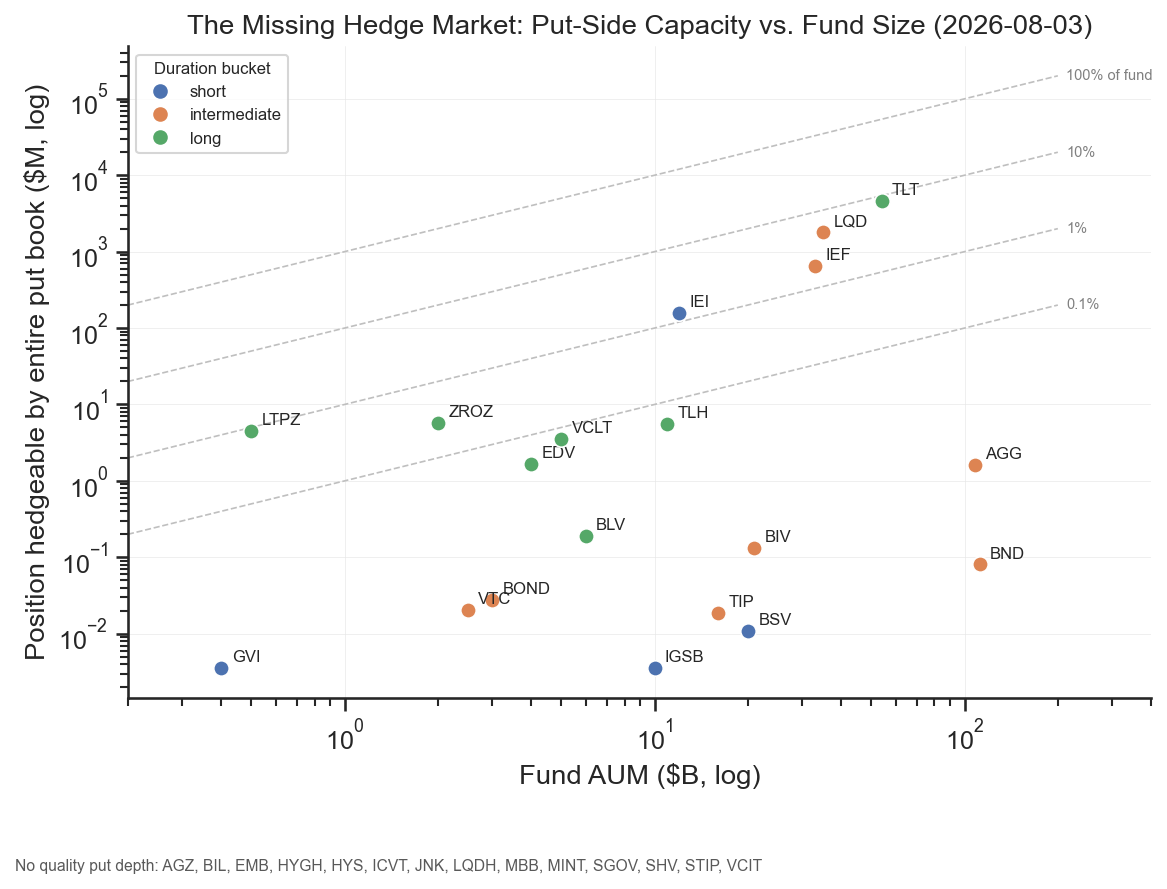

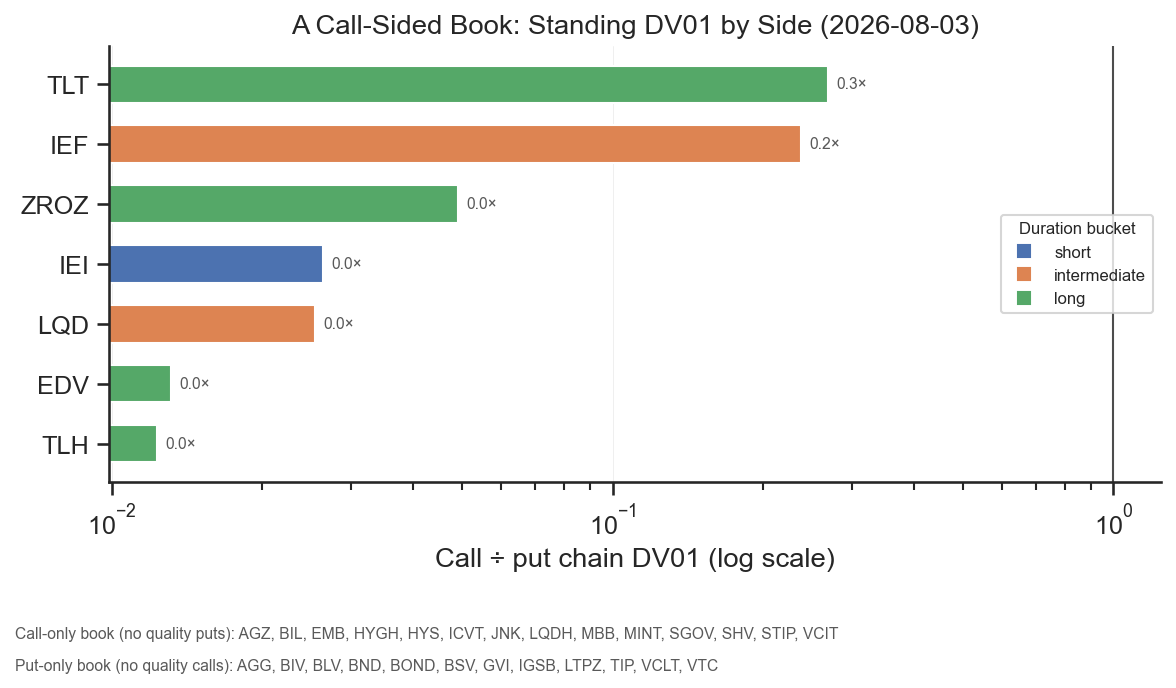

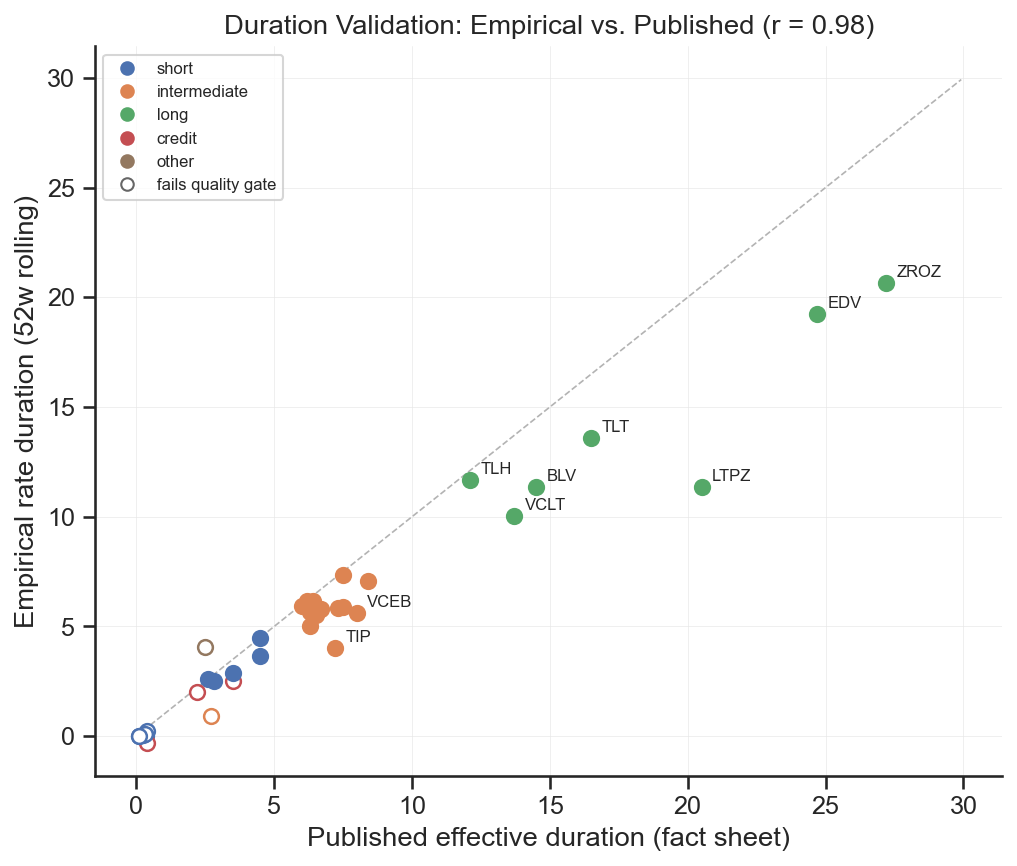

In [32]:
# ── Paper figures (read-only) — produced by scripts/08_paper_artifacts.py ─
from IPython.display import Image, display as idisplay
for f in ["24_missing_market.png", "25_call_put_ratio.png", "26_duration_validation.png"]:
    p = cfg.FIGURES_DIR / f
    if p.exists():
        idisplay(Image(filename=str(p)))
    else:
        print(f"{f} absent — run scripts/08_paper_artifacts.py")